# Exercícios de Escoamento Potencial — Superposição de Soluções Elementares

Tradução em Python dos scripts MATLAB da pasta `Exercícios` (`ez.m`, `ez2.m`, `slide2_ex1.m`,
`slide2_ex3.m`, `slide2_ex5.m`). Cada seção reproduz o mesmo modelo físico e os mesmos
parâmetros do script original, usando `numpy`/`matplotlib` no lugar de `ezplot`:

1. Cilindro em escoamento uniforme (escoamento uniforme + dipolo);
2. Cilindro com circulação (escoamento uniforme + dipolo + vórtice);
3. Fonte/sumidouro isolado na origem;
4. Vórtice isolado na origem;
5. Corpos de Rankine — meio-corpo (fonte + escoamento uniforme) e oval (fonte+sumidouro
   + escoamento uniforme).

Em todos os casos, as linhas de corrente são obtidas plotando curvas de nível da função
corrente $\psi(x,y)$, em vez do traçado implícito ponto-a-ponto do `ezplot`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('ggplot')

## 1. Cilindro em escoamento uniforme (`ez.m`)

Superposição de um escoamento uniforme de velocidade $U=2$ com um dipolo de intensidade
equivalente a um cilindro de raio $R=1$:
$$\psi(x,y) = Uy - \dfrac{UR^2y}{x^2+y^2}$$
O script original desenha a linha de corrente $\psi=0$ (superfície do cilindro) e, através
de deslocamentos sucessivos da constante, as linhas $\psi = \pm0.5, \pm1, \pm1.5$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


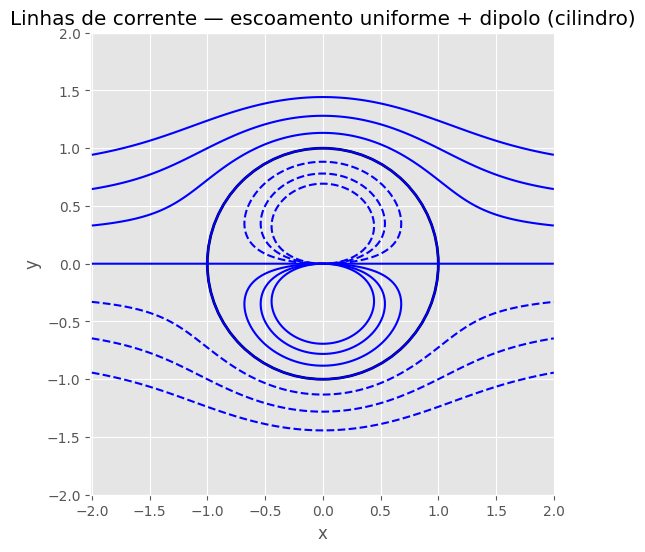

In [2]:
U = 2   # velocidade do escoamento uniforme
R = 1   # raio do cilindro (intensidade do dipolo)

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

with np.errstate(divide='ignore', invalid='ignore'):
    psi = U * Y - (U * R**2 * Y) / (X**2 + Y**2)

levels = [-1.5, -1, -0.5, 0, 0.5, 1, 1.5]

plt.figure(figsize=(6, 6))
plt.contour(X, Y, psi, levels=levels, colors='b')
plt.gca().add_patch(plt.Circle((0, 0), R, color='k', fill=False, linewidth=2))
plt.axis('equal')
plt.xlim(-2, 2); plt.ylim(-2, 2)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Linhas de corrente — escoamento uniforme + dipolo (cilindro)')
plt.show()

## 2. Cilindro com circulação (`ez2.m`)

Acrescenta-se um vórtice na origem à superposição anterior, gerando o efeito Magnus
(sustentação sobre o cilindro):
$$\psi(x,y) = Uy - \dfrac{UR^2y}{x^2+y^2} - \ln(x^2+y^2)$$
Novamente, as mesmas 7 curvas de nível de $\psi$ do item anterior são plotadas.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


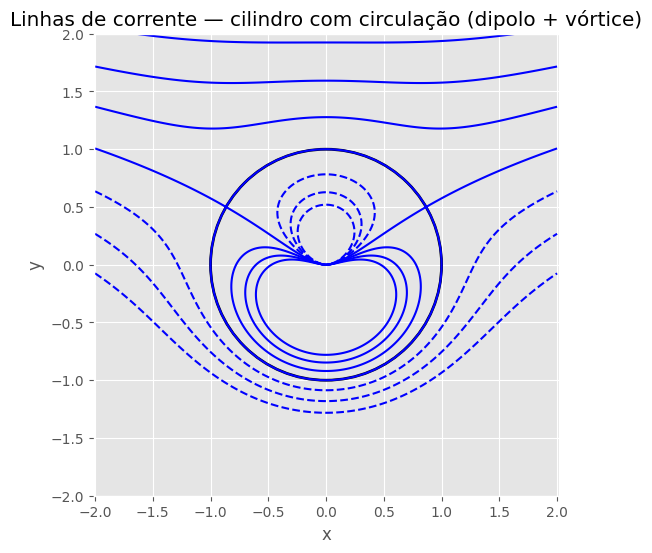

In [3]:
U = 2
R = 1

x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

with np.errstate(divide='ignore', invalid='ignore'):
    psi = U * Y - (U * R**2 * Y) / (X**2 + Y**2) - np.log(X**2 + Y**2)

levels = [-1.5, -1, -0.5, 0, 0.5, 1, 1.5]

plt.figure(figsize=(6, 6))
plt.contour(X, Y, psi, levels=levels, colors='b')
plt.gca().add_patch(plt.Circle((0, 0), R, color='k', fill=False, linewidth=2))
plt.axis('equal')
plt.xlim(-2, 2); plt.ylim(-2, 2)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Linhas de corrente — cilindro com circulação (dipolo + vórtice)')
plt.show()

## 3. Fonte/sumidouro isolado (`slide2_ex1.m`)

Para uma fonte ($m>0$) ou sumidouro ($m<0$) 2D na origem, a função corrente
$\psi=m\theta/(2\pi)$ depende apenas do ângulo $\theta=\mathrm{atan2}(y,x)$: as linhas de
corrente são raios saindo da origem. A segunda figura mostra a mesma função corrente
$\psi=m\,\mathrm{atan2}(y,x)$ via curvas de nível.

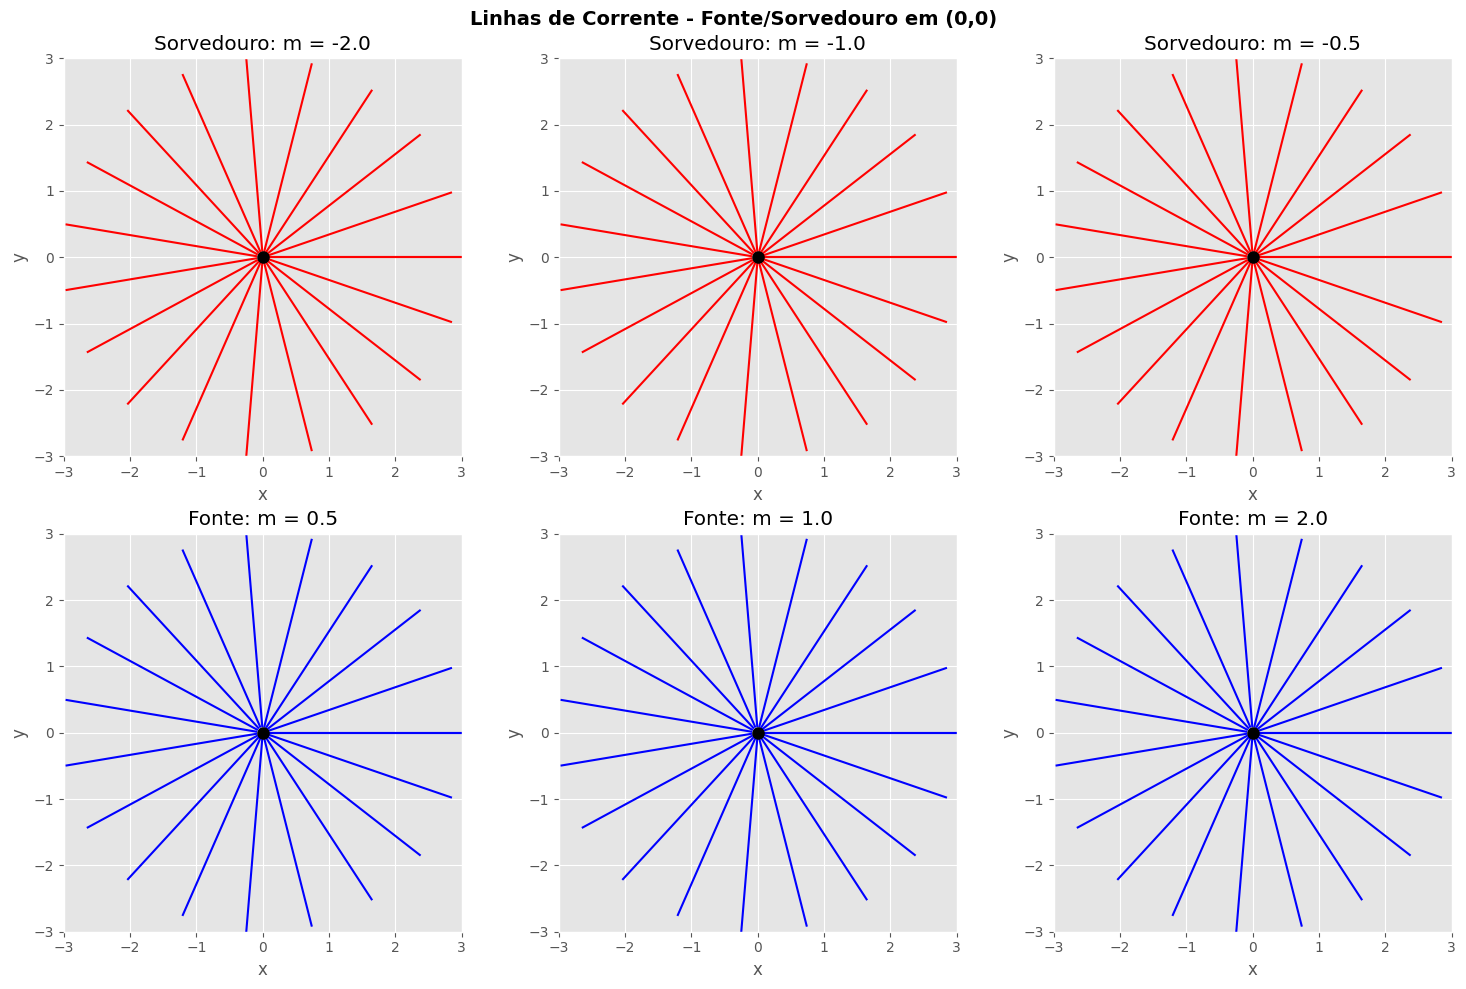

In [4]:
valores_m = [-2, -1, -0.5, 0.5, 1, 2]

theta = np.linspace(0, 2 * np.pi, 20)
r = np.linspace(0.1, 3, 10)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, m in zip(axes.flat, valores_m):
    tipo = 'Fonte' if m >= 0 else 'Sorvedouro'
    cor = 'b' if m >= 0 else 'r'
    for th in theta:
        x_line = r * np.cos(th)
        y_line = r * np.sin(th)
        ax.plot(x_line, y_line, color=cor, linewidth=1.5)
    ax.plot(0, 0, 'ko', markersize=8)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_title(f'{tipo}: m = {m:.1f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.grid(True)
fig.suptitle('Linhas de Corrente - Fonte/Sorvedouro em (0,0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

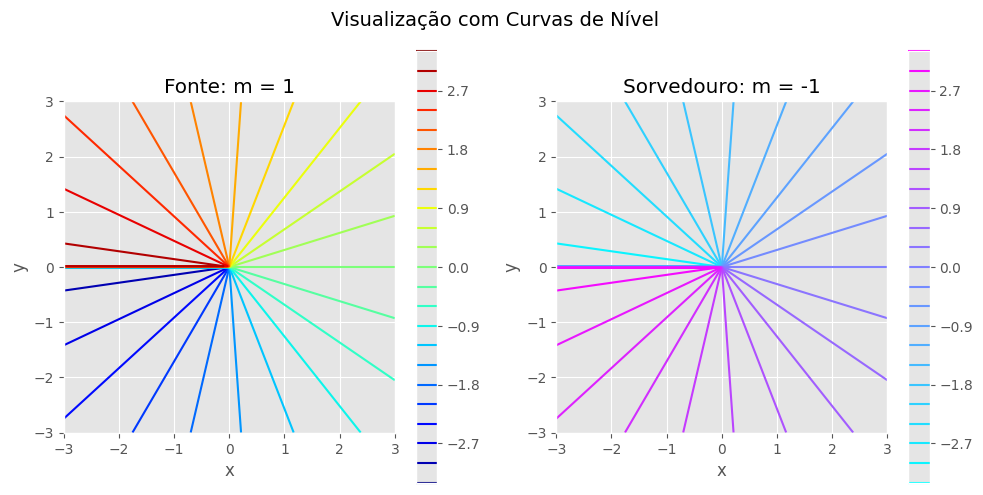

In [5]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, m in zip(axes, [1, -1]):
    psi = m * np.arctan2(Y, X)
    cs = ax.contour(X, Y, psi, levels=20, cmap='jet' if m > 0 else 'cool')
    ax.set_title('Fonte: m = 1' if m > 0 else 'Sorvedouro: m = -1')
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.grid(True)
    fig.colorbar(cs, ax=ax)
fig.suptitle('Visualização com Curvas de Nível', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Vórtice isolado (`slide2_ex3.m`)

Função corrente de um vórtice de intensidade (circulação) $\Gamma$ na origem:
$$\psi(x,y) = \dfrac{\Gamma}{2\pi}\ln\sqrt{x^2+y^2}$$
As linhas de corrente são círculos concêntricos à origem; o sinal de $\Gamma$ define o
sentido de rotação. (No script MATLAB original, o `ezplot` de uma única string plota apenas
a curva de nível $\psi=0$, que degenera no círculo unitário para qualquer $\Gamma\neq0$;
aqui usam-se várias curvas de nível para mostrar corretamente a família de círculos que o
modelo representa.)

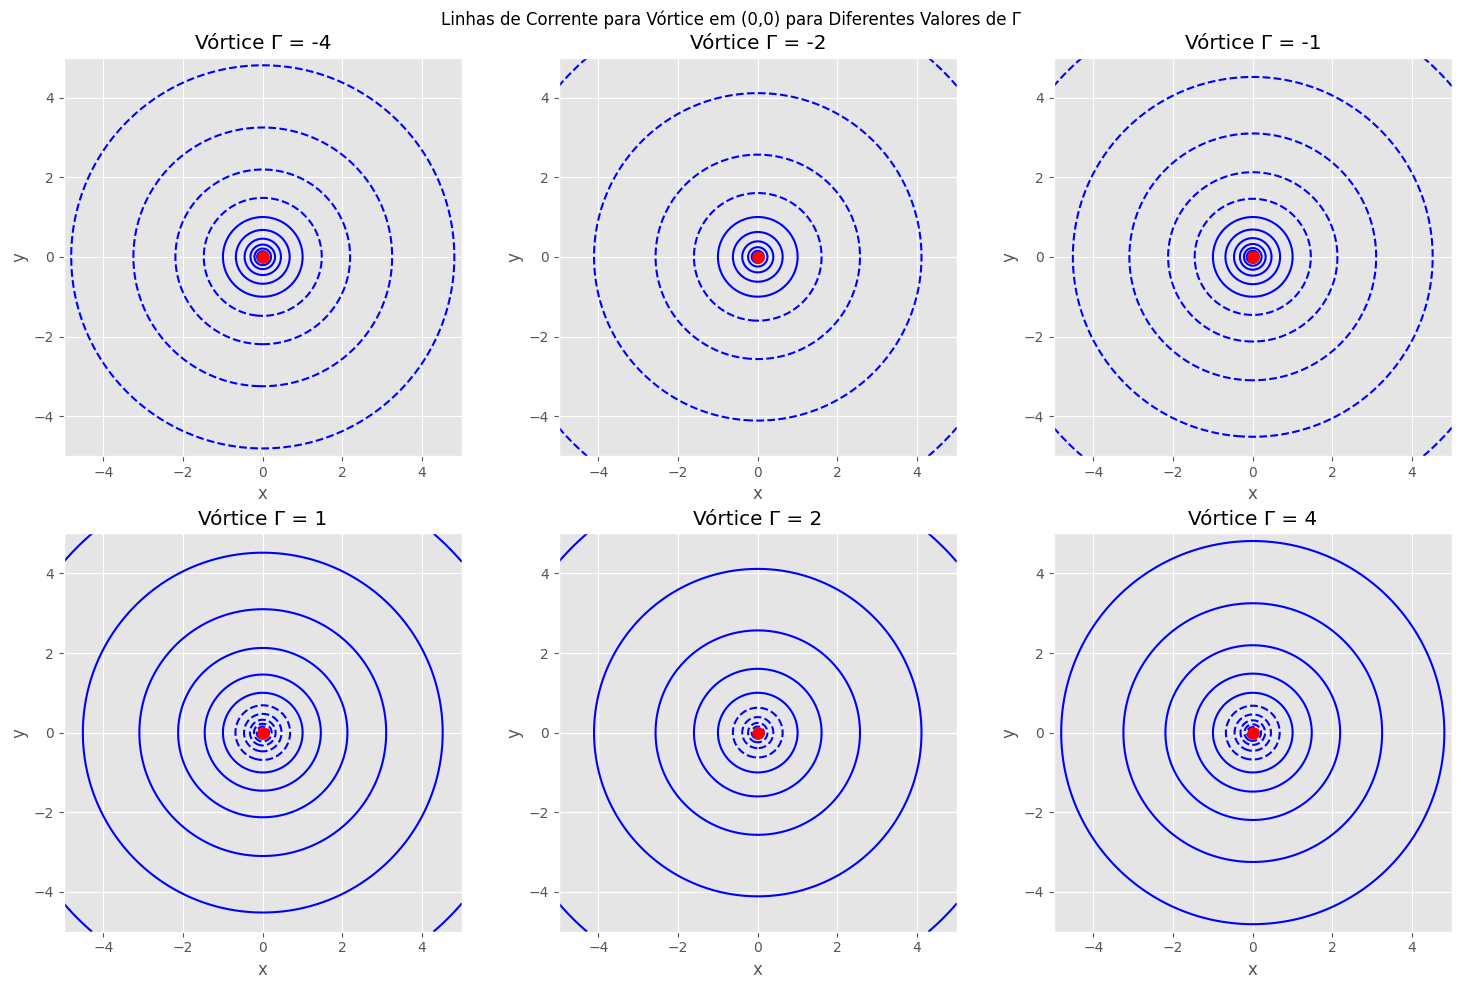

In [6]:
gammas = [-4, -2, -1, 1, 2, 4]

x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, gamma in zip(axes.flat, gammas):
    with np.errstate(divide='ignore'):
        psi = (gamma / (2 * np.pi)) * np.log(r)
    ax.contour(X, Y, psi, levels=15, colors='b')
    ax.plot(0, 0, 'ro', markersize=8)
    ax.set_title(f'Vórtice Γ = {gamma}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(True)
fig.suptitle('Linhas de Corrente para Vórtice em (0,0) para Diferentes Valores de Γ')
plt.tight_layout()
plt.show()

## 5. Corpos de Rankine (`slide2_ex5.m`)

**Caso (a)** — escoamento uniforme $U$ + fonte/sumidouro de intensidade $m$ em $(a,0)$,
gerando um **meio-corpo de Rankine**:
$$\psi(x,y) = Uy + \dfrac{m}{2\pi}\,\mathrm{atan2}(y, x-a)$$

**Caso (b)** — escoamento uniforme + fonte em $(-a,0)$ e sumidouro em $(a,0)$, gerando uma
**oval de Rankine** (corpo fechado):
$$\psi(x,y) = Uy + \dfrac{m}{2\pi}\Big[\mathrm{atan2}(y,x+a) - \mathrm{atan2}(y,x-a)\Big]$$

Ambos os casos são avaliados para as três combinações $(U,m,a)$ do script original.

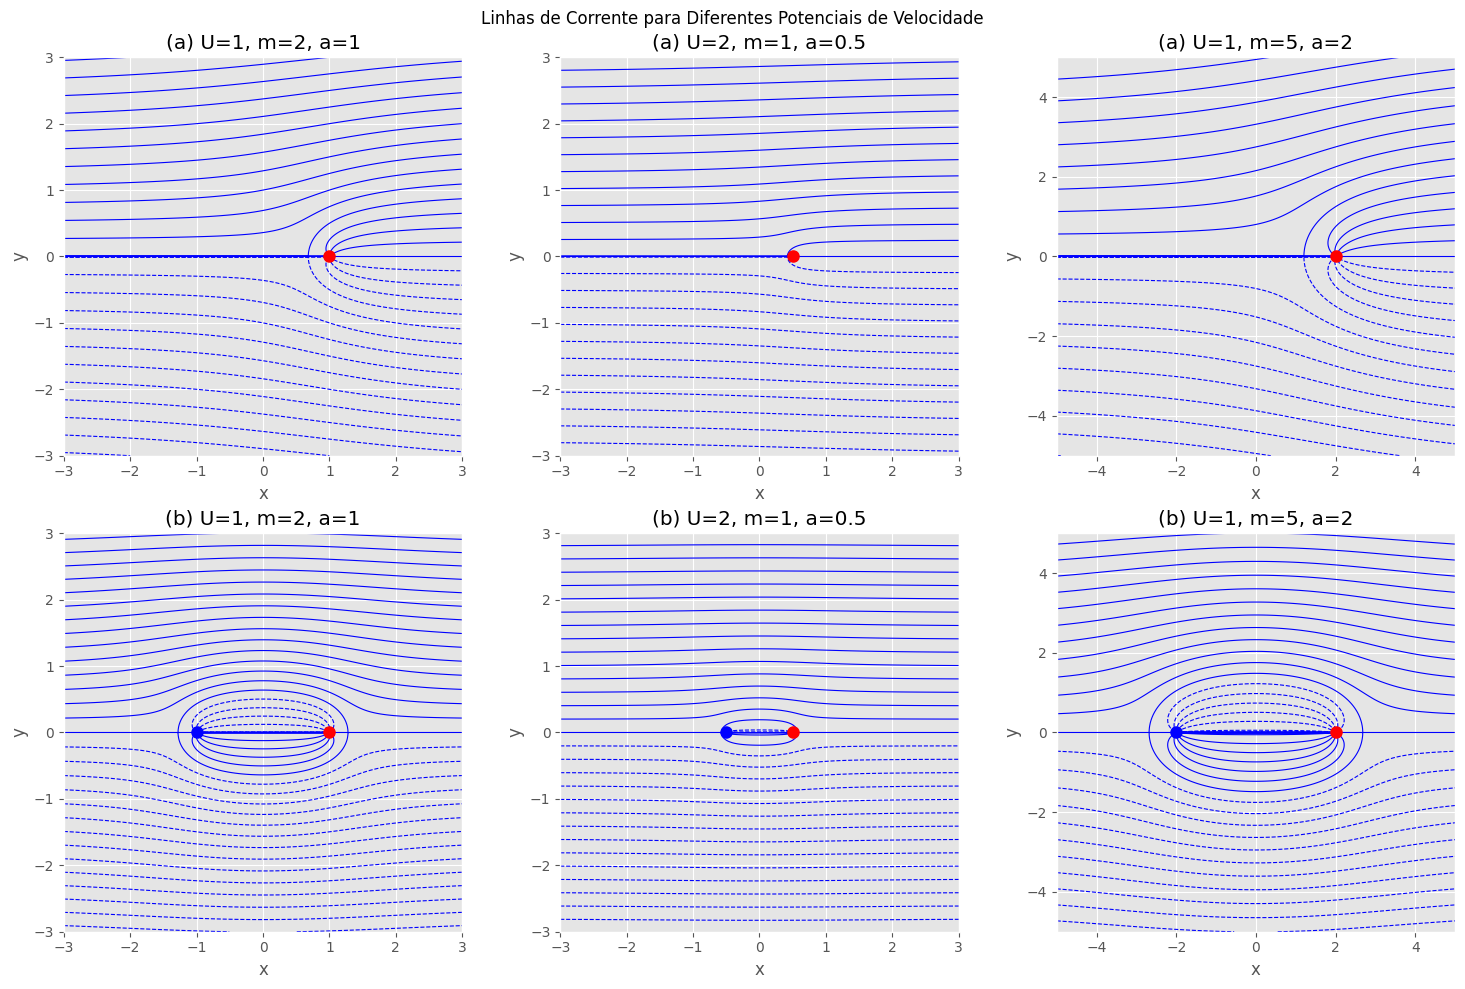

In [7]:
def psi_a(x, y, U, m, a):
    """Escoamento uniforme + fonte/sumidouro em (a,0) -> meio-corpo de Rankine."""
    return U * y + (m / (2 * np.pi)) * np.arctan2(y, x - a)


def psi_b(x, y, U, m, a):
    """Escoamento uniforme + fonte em (-a,0) e sumidouro em (a,0) -> oval de Rankine."""
    return U * y + (m / (2 * np.pi)) * (np.arctan2(y, x + a) - np.arctan2(y, x - a))


configs = [(1, 2, 1), (2, 1, 0.5), (1, 5, 2)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for k, (U, m, a) in enumerate(configs):
    lim = 3 if a <= 1 else 5
    x = np.linspace(-lim, lim, 300)
    y = np.linspace(-lim, lim, 300)
    X, Y = np.meshgrid(x, y)

    ax = axes[0, k]
    ax.contour(X, Y, psi_a(X, Y, U, m, a), levels=30, colors='b', linewidths=0.8)
    ax.plot(a, 0, 'ro', markersize=8)
    ax.set_title(f'(a) U={U}, m={m}, a={a}')
    ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlabel('x'); ax.set_ylabel('y')

    ax = axes[1, k]
    ax.contour(X, Y, psi_b(X, Y, U, m, a), levels=30, colors='b', linewidths=0.8)
    ax.plot(-a, 0, 'bo', markersize=8)
    ax.plot(a, 0, 'ro', markersize=8)
    ax.set_title(f'(b) U={U}, m={m}, a={a}')
    ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle('Linhas de Corrente para Diferentes Potenciais de Velocidade')
plt.tight_layout()
plt.show()